# Supplementary Figures (Figs. S1–S6)

This notebook generates all six supplementary figures.  Like `main_figures.ipynb`, it reads pre-computed posteriors and CSV tables from `results/` and writes PDFs to `figures/`.

| Figure | Content | Output file |
|--------|---------|-------------|
| **Fig. S1** | Validation of the QSS approximation: full two-ODE model vs. reduced logistic | `figures/figS1.pdf` |
| **Figs. S2–S5** | Same four-panel layout as Fig. 1, for biological replicates 1, 3, 4, 5 | `figures/figS2.pdf` – `figS5.pdf` |
| **Fig. S6** | Sensitivity analysis: fixed α vs. free α across the medium perturbations | `figures/figS6.pdf` |

**Prerequisites:** run `cip_model_bayesian_inference.ipynb` first.

In [1]:
from functions import *

---
## Figure S1 — Validation of the quasi-steady-state (QSS) approximation

The five-parameter logistic model used throughout the paper is derived from a two-ODE system that tracks replication fork density $f(t)$ and cell density $N(t)$ (manuscript Eq. 1–2):

$$\dot{f} = \left(1 - \frac{N}{K_0}\right)\left(\frac{r_0}{1+(c/c_0)^\alpha}\,N - d\,f\right)$$
$$\dot{N} = \left(1 - \frac{N}{K_0}\right)d\,f - q\,c\,N$$

When fork turnover $d$ is large (fast QSS), the fork density relaxes rapidly to its steady-state value and the system reduces to the single logistic ODE (Eq. 3).  This figure validates that approximation by overlaying numerical solutions of the full two-ODE system (solid lines) and the reduced logistic (dashed lines) for three values of $d$ (5, 10, 25 h⁻¹) and four CIP concentrations.

The parameter values used here are the posterior means from replicate 2 of the standard condition.

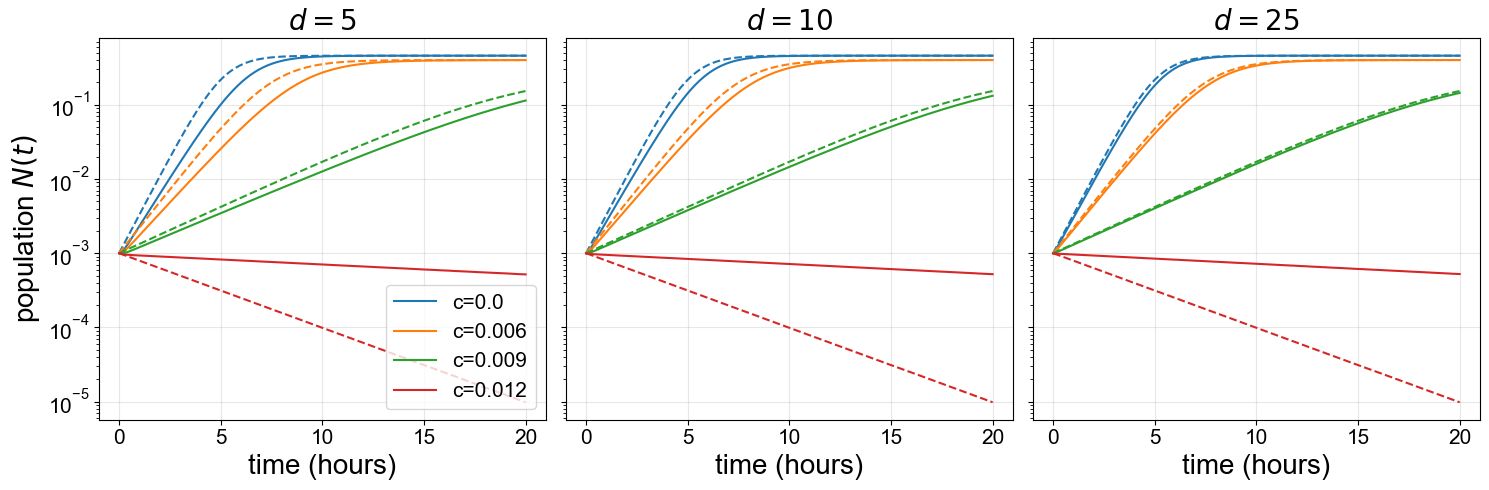

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Posterior mean parameters from the standard-condition fit (replicate 2)
r0    = 1.204
K0    = 0.459
q     = 19.307
c0    = 0.008
alpha = 3.982

# Fork turnover rates to test (h^-1); large d = fast QSS = good approximation
d_values = [5, 10, 25]

# CIP concentrations spanning sub-MIC to supra-MIC
# (MIC ~ 0.012 ug/mL for these parameters)
c_values = [0.0, 0.006, 0.009, 0.012]


def full_model(t, y, d, c):
    """
    Full two-ODE system (Eq. 1–2).
    y = [f, N] where f is replication fork density and N is cell density.
    The (1 - N/K0) factor accounts for density-dependent growth inhibition.
    """
    f, N   = y
    term1  = (1 - N / K0)    # logistic crowding term (shared by both equations)
    dfdt   = term1 * (r0 / (1 + (c / c0) ** alpha) * N - d * f)  # fork dynamics
    dNdt   = term1 * d * f - q * c * N                            # cell dynamics
    return [dfdt, dNdt]


def qss_model(t, N, c):
    """
    QSS-reduced logistic model (Eq. 3).
    r(c) and K(c) are the CIP-dependent effective growth rate and carrying capacity.
    """
    r_c = r0 / (1 + (c / c0) ** alpha) - q * c
    K_c = K0 * (1 - (q * c / r0) * (1 + (c / c0) ** alpha))

    # Above the MIC, r_c and K_c become negative: population decays
    if K_c <= 0 or r_c <= 0:
        return -q * c * N   # simple exponential decay at supra-MIC concentrations

    return r_c * N * (1 - N / K_c)  # standard logistic growth


# Simulation settings
t_span = (0, 20)
t_eval = np.linspace(0, 20, 400)
N0     = 0.001  # initial cell density (matches the experimental inoculum)
y0_2d  = [0.0, N0]  # full model: start with zero fork density to see the transient

fig, axes = plt.subplots(1, len(d_values), figsize=(15, 5), sharey=True)

for i, d in enumerate(d_values):
    ax = axes[i]

    for c in c_values:
        # Integrate the full two-ODE model
        sol_full = solve_ivp(full_model, t_span, y0_2d, args=(d, c), t_eval=t_eval)
        # Integrate the QSS-reduced logistic
        sol_qss  = solve_ivp(qss_model,  t_span, [N0],  args=(c,),   t_eval=t_eval)

        # Solid = full model (N component only); dashed = QSS logistic
        line, = ax.plot(sol_full.t, sol_full.y[1], label=f'c={c}')
        ax.plot(sol_qss.t, sol_qss.y[0], '--', color=line.get_color())

    ax.set_title(f'$d={d}$', fontsize=20)
    ax.set_xlabel('time (hours)', fontsize=20)

    if i == 0:
        ax.set_ylabel('population $N(t)$', fontsize=20)
        ax.legend(fontsize=15, loc='lower right')

    ax.grid(alpha=0.3)
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=15)
    ax.set_yticks([1e-4, 1e-3, 1e-2, 1e-1, 1])
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)
    ax.set_yscale('log')  # log scale to show dynamics across the full OD range

plt.tight_layout()
fig.savefig('figures/figS1.pdf', bbox_inches='tight')

---
## Figures S2–S5 — Biological replicates 1, 3, 4, 5

These four figures reproduce the same four-panel layout as Fig. 1 (panels A–D) for the remaining biological replicates.
The layout is identical and the code is structured as a loop over `rep ∈ {1, 3, 4, 5}` (note: replicate 2 is already shown in Fig. 1).

Showing all five replicates here confirms that the performance of the mechanistic model and the failure mode of the independent logistic fits are reproducible across experimental days and batches.

Supplementary figure numbering: replicate 1 → S2, replicate 3 → S3, replicate 4 → S4, replicate 5 → S5.

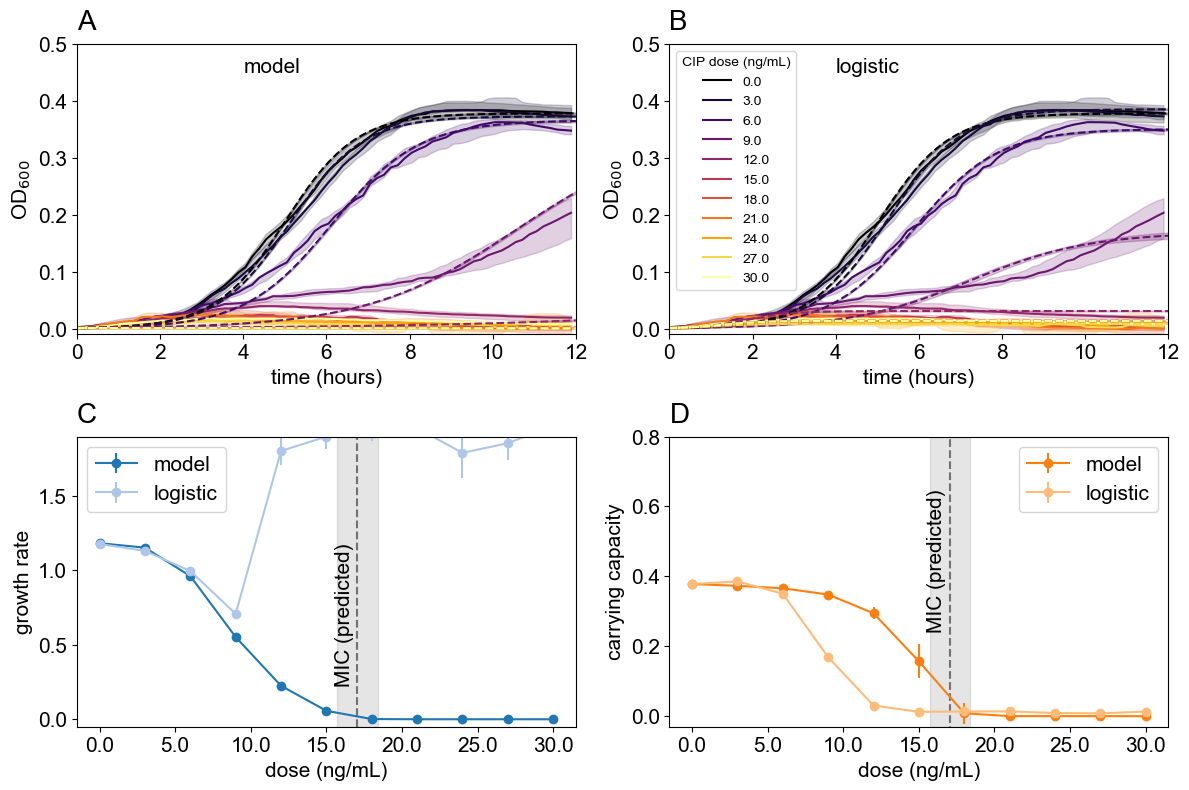

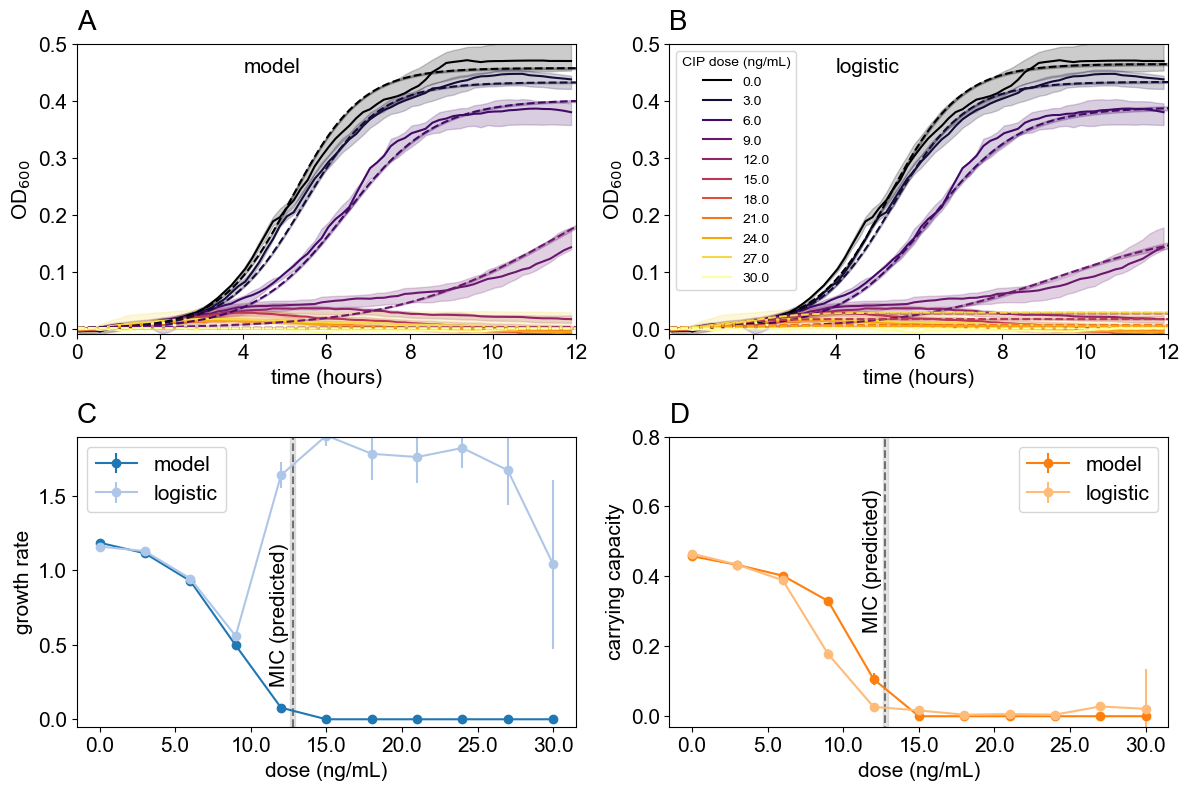

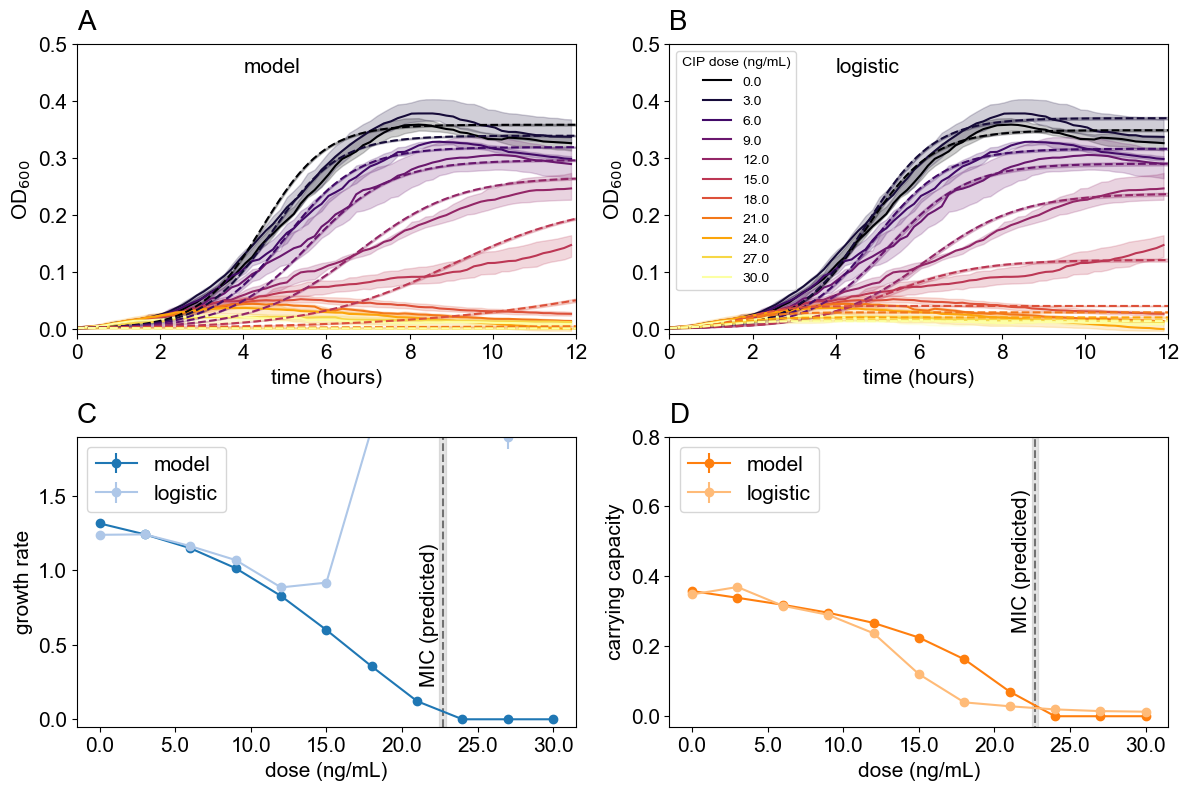

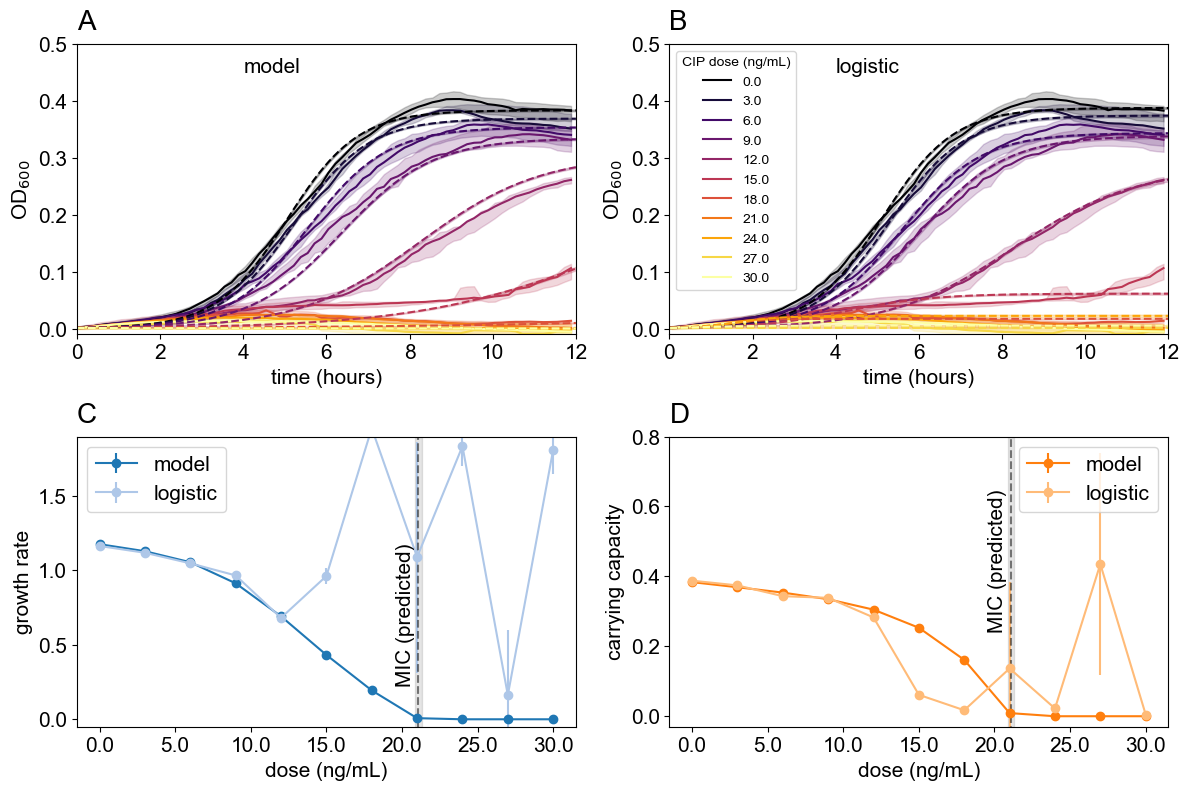

In [3]:
medium = 'standard'
y0     = 0.001

DF     = pd.read_csv('data/cip_dose_response_all.csv')
DF_CIP = DF[(DF.medium == medium) & (DF.Hours < 12)]

# Color map: same inferno palette used in Fig. 1
unique_doses = sorted(DF_CIP['dosisAb'].unique())
colors       = plt.get_cmap('inferno', len(unique_doses))
color_dict   = {dose: colors(i) for i, dose in enumerate(unique_doses)}

# irep indexes into the figure numbering (S2, S3, S4, S5)
for irep, rep in enumerate([1, 3, 4, 5]):

    fig = plt.figure(figsize=(12, 8))

    filename = f"results/cip_model_standard_{rep}_12h.nc"

    # ------------------------------------------------------------------
    # Panel A: data (median + IQR) + mechanistic model posterior predictive
    # ------------------------------------------------------------------
    ax = fig.add_subplot(2, 2, 1)
    by_label = plot_data(DF_CIP[DF_CIP.rep == rep], ax)
    plot_pred(ax, filename, unique_doses, y0)
    ax.set_xlim([0, 12])
    ax.set_ylim([-0.01, 0.5])
    ax.text(4, 0.45, 'model', fontsize=15)
    ax.tick_params(labelsize=15)
    ax.text(0.0, 1.05, 'A', fontsize=20, transform=ax.transAxes)
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)

    # ------------------------------------------------------------------
    # Panel B: same data + independent per-curve logistic fits
    # ------------------------------------------------------------------
    ax = fig.add_subplot(2, 2, 2)
    by_label = plot_data(DF_CIP[DF_CIP.rep == rep], ax)
    plot_pred_logistic(rep, ax, unique_doses, y0)
    ax.legend(by_label.values(), by_label.keys(),
              title="CIP dose (ng/mL)", ncols=1, loc='upper left')
    ax.set_xlim([0, 12])
    ax.set_ylim([-0.01, 0.5])
    ax.text(4, 0.45, 'logistic', fontsize=15)
    ax.tick_params(labelsize=15)
    ax.text(0.0, 1.05, 'B', fontsize=20, transform=ax.transAxes)
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)

    # Load the posterior MIC for this replicate (used in panels C and D)
    idata          = az.from_netcdf(filename)
    MICavg, MICstd = get_mic(idata)

    # Load the pre-computed r/K summary table
    rK     = pd.read_csv(f'results/rK_{rep}_12h.csv')
    colors = plt.get_cmap('tab20')

    # ------------------------------------------------------------------
    # Panel C: growth rate r(c) — mechanistic model vs. independent logistic
    # ------------------------------------------------------------------
    ax = fig.add_subplot(2, 2, 3)
    ax.errorbar(rK.c, rK.Ravg,  yerr=rK.Rstd,  marker='o', color=colors(0), label='model')
    ax.errorbar(rK.c, rK.RavgL, yerr=rK.RstdL, marker='o', color=colors(1), label='logistic')
    ax.set_xlabel('dose (ng/mL)', fontsize=15)
    ax.set_ylabel('growth rate', fontsize=15)
    ax.set_ylim([-0.05, 1.9])
    # Vertical dashed line marks the posterior mean MIC; shaded band = ±1 SD
    ax.vlines(MICavg, ymin=-0.05, ymax=1.9, ls='dashed', color='k', alpha=0.5)
    ax.fill_between([MICavg - MICstd, MICavg + MICstd], -0.05, 1.9,
                    alpha=0.1, color='k')
    ax.text(MICavg - 0.0015, 0.25, 'MIC (predicted)', rotation=90, fontsize=15)
    ax.legend(fontsize=15)
    ax.tick_params(labelsize=15)
    ax.text(0.0, 1.05, 'C', fontsize=20, transform=ax.transAxes)
    # Convert x-axis from ug/mL to ng/mL
    Ticks = np.arange(0, 0.031, 0.005)
    ax.set_xticks(Ticks)
    ax.set_xticklabels([1000 * z for z in Ticks])

    # ------------------------------------------------------------------
    # Panel D: carrying capacity K(c) — mechanistic model vs. independent logistic
    # ------------------------------------------------------------------
    ax = fig.add_subplot(2, 2, 4)
    ax.errorbar(rK.c, rK.Kavg,  yerr=rK.Kstd,  marker='o', color=colors(2), label='model')
    ax.errorbar(rK.c, rK.KavgL, yerr=rK.KstdL, marker='o', color=colors(3), label='logistic')
    ax.set_xlabel('dose (ng/mL)', fontsize=15)
    ax.set_ylabel('carrying capacity', fontsize=15)
    ax.set_ylim([-0.03, 0.8])
    ax.vlines(MICavg, ymin=-0.05, ymax=0.8, ls='dashed', color='k', alpha=0.5)
    ax.fill_between([MICavg - MICstd, MICavg + MICstd], -0.03, 0.8,
                    alpha=0.1, color='k')
    ax.text(MICavg - 0.0015, 0.25, 'MIC (predicted)', rotation=90, fontsize=15)
    ax.legend(fontsize=15)
    ax.tick_params(labelsize=15)
    ax.text(0.0, 1.05, 'D', fontsize=20, transform=ax.transAxes)
    Ticks = np.arange(0, 0.031, 0.005)
    ax.set_xticks(Ticks)
    ax.set_xticklabels([1000 * z for z in Ticks])

    fig.tight_layout()
    # irep+2 maps replicate indices {0,1,2,3} to figure numbers {S2,S3,S4,S5}
    fig.savefig(f'figures/figS{irep + 2}.pdf', bbox_inches='tight')

---
## Figure S6 — Sensitivity analysis: fixed vs. free Hill coefficient α

This figure mirrors Fig. 4 but uses the **fixed-α posteriors** from `fit_model_fixed_alpha()` (Section 7 of the inference notebook).  Fixing $\alpha$ at its global mean (6.21) effectively removes one degree of freedom from the posterior and reduces the posterior uncertainty of $q$ and $c_0$.  The question is whether the main findings of Fig. 4 are preserved.

As discussed in the manuscript:
- For most conditions the $r_0$–$q$ correlation and $r_0$–MIC dichotomy are reproduced.
- For CHL at 6.0 µg/mL the fixed-α model fails: the growth curves are so strongly suppressed that $\alpha$ is not identifiable, and fixing it at 6.21 forces $r_0$ to an unrealistically large value.

This confirms that the free-$\alpha$ formulation is preferable for general use.

In [9]:
# One color per experimental condition
conditions = ["glucose", "glycerol", "TMP", "CHL"]
colors     = {'glucose': 'blue', 'TMP': 'red', 'glycerol': 'green', 'CHL': 'purple'}

df = pd.read_csv("results/parameters_table_fixed_alpha.csv")

# -----------------------------------------------------------------------
# Bayesian linear regression for TMP: q ~ a + b * r0
# Used to draw the posterior-predictive band in panel A.
# -----------------------------------------------------------------------
def line(x, a, b):
    return a + b * x

dfTMP = df[df.medium == 'TMP']
with pm.Model() as generative_model:
    x = pm.Data("r0", dfTMP.r0_mean)
    y = pm.Data("q",  dfTMP.q_mean)
    a     = pm.Normal('a', sigma=40)
    b     = pm.Normal('b', sigma=40)
    sigma = pm.HalfNormal('sigma')
    likelihood = pm.Normal("y_obs", mu=line(x, a, b), sigma=sigma, observed=y)
    idataTMP = pm.sample(draws=1000, tune=2000, target_accept=0.95,
                         cores=4, return_inferencedata=True)

# Bayesian linear regression for CHL: same model
dfCHL = df[df.medium == 'CHL']
with pm.Model() as generative_model:
    x = pm.Data("r0", dfCHL.r0_mean)
    y = pm.Data("q",  dfCHL.q_mean)
    a     = pm.Normal('a', sigma=40)
    b     = pm.Normal('b', sigma=40)
    sigma = pm.HalfNormal('sigma')
    likelihood = pm.Normal("y_obs", mu=a + b * x, sigma=sigma, observed=y)
    idataCHL = pm.sample(draws=1000, tune=2000, target_accept=0.99,
                         cores=4, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 12 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [10]:
# Optional: quick summary of the TMP linear regression coefficients
az.summary(idataTMP)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-12.314,3.557,-19.290,-5.695,0.104,0.085,1206.0,1475.0,1.0
b,35.102,4.518,26.098,43.635,0.131,0.112,1227.0,1267.0,1.0
sigma,1.935,0.489,1.095,2.832,0.013,0.009,1226.0,1178.0,1.0


In [11]:
# Optional: quick summary of the CHL linear regression coefficients
az.summary(idataCHL)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-24.185,1.312,-26.495,-21.889,0.080,0.173,357.0,345.0,1.01
b,44.103,1.724,41.245,47.231,0.107,0.220,341.0,318.0,1.01
sigma,0.392,0.432,0.017,1.202,0.028,0.027,208.0,602.0,1.01


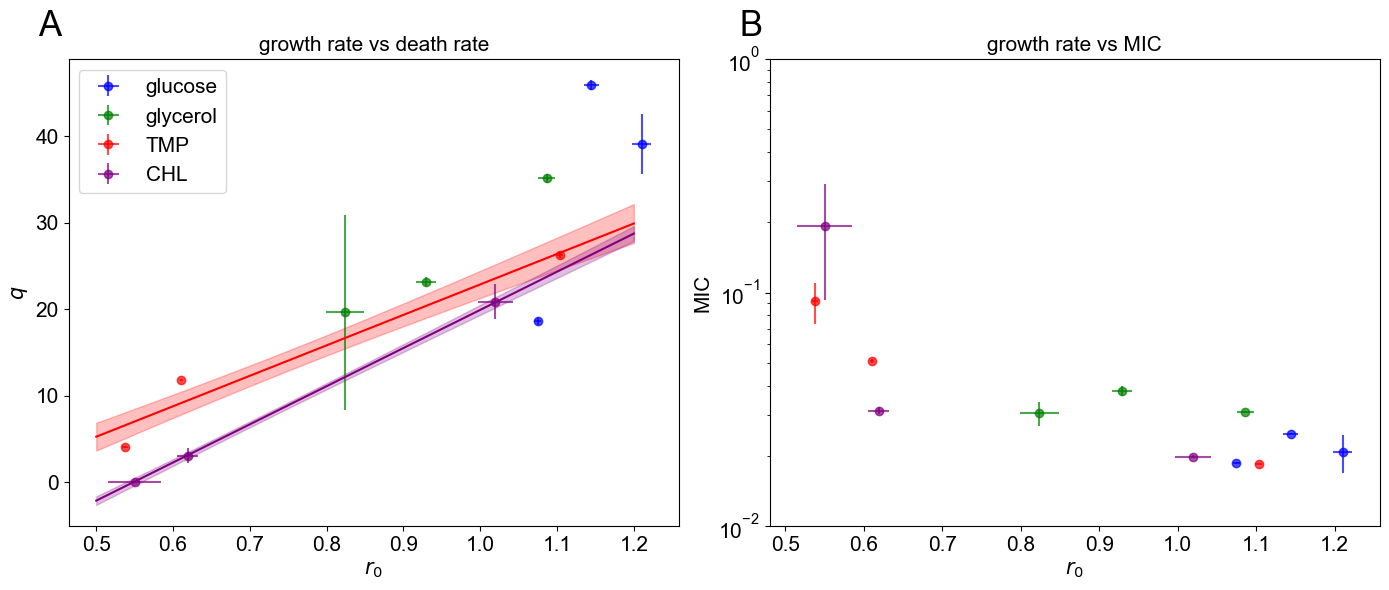

In [12]:
conditions = ["glucose", "glycerol", "TMP", "CHL"]
colors     = {'glucose': 'blue', 'TMP': 'red', 'glycerol': 'green', 'CHL': 'purple'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Load the parameter table produced by the fixed-alpha fits
file_path = "results/parameters_table_fixed_alpha.csv"
df        = pd.read_csv(file_path)

for cond in conditions:
    try:
        df_cond = pd.read_csv(file_path)
        df_cond = df_cond[df_cond.medium == cond]

        # Panel A: q vs r0 (same axes as Fig. 4A for direct visual comparison)
        ax1.errorbar(
            df_cond['r0_mean'], df_cond['q_mean'],
            xerr=df_cond['r0_std'], yerr=df_cond['q_std'],
            fmt='o', label=cond, color=colors[cond], alpha=0.7
        )

        # Panel B: MIC vs r0 (log scale, same as Fig. 4B)
        ax2.errorbar(
            df_cond['r0_mean'], df_cond['MIC_mean'],
            xerr=df_cond['r0_std'], yerr=df_cond['MIC_std'],
            fmt='o', label=cond, color=colors[cond], alpha=0.7
        )

    except FileNotFoundError:
        print(f"Warning: {file_path} not found. Skipping {cond}...")

# ------------------------------------------------------------------
# Overlay posterior-predictive band for the TMP linear trend (Panel A)
# ------------------------------------------------------------------
posterior = idataTMP.posterior.stack(samples=("draw", "chain"))
all_sims  = []
xp = np.linspace(0.5, 1.2, 100)
for i in np.random.randint(0, posterior.samples.size, 1000):
    ai     = posterior["a"].values[i]
    bi     = posterior["b"].values[i]
    all_sims.append(ai + bi * xp)
average_sim = np.mean(all_sims, axis=0)
std_sim     = np.std(all_sims, axis=0)
ax1.plot(xp, average_sim, ls='-', color=colors['TMP'])
ax1.fill_between(xp, average_sim - std_sim, average_sim + std_sim,
                 color=colors['TMP'], alpha=0.25)

# Overlay posterior-predictive band for the CHL linear trend (Panel A)
posterior = idataCHL.posterior.stack(samples=("draw", "chain"))
all_sims  = []
for i in np.random.randint(0, posterior.samples.size, 1000):
    ai = posterior["a"].values[i]
    bi = posterior["b"].values[i]
    all_sims.append(ai + bi * xp)
average_sim = np.mean(all_sims, axis=0)
std_sim     = np.std(all_sims, axis=0)
ax1.plot(xp, average_sim, ls='-', color=colors['CHL'])
ax1.fill_between(xp, average_sim - std_sim, average_sim + std_sim,
                 color=colors['CHL'], alpha=0.25)

# ------------------------------------------------------------------
# Formatting — intentionally mirrors Fig. 4 for side-by-side comparison
# ------------------------------------------------------------------
ax1.set_xlabel(r'$r_0$', fontsize=15)
ax1.set_ylabel(r'$q$', fontsize=15)
ax1.set_title(r'growth rate vs death rate', fontsize=15)
ax1.legend(fontsize=15)
ax1.text(-0.05, 1.05, 'A', transform=ax1.transAxes, fontsize=25)
ax1.tick_params(labelsize=15)

ax2.set_xlabel(r'$r_0$', fontsize=15)
ax2.set_ylabel('MIC', fontsize=15)
ax2.set_title(r'growth rate vs MIC', fontsize=15)
ax2.text(-0.05, 1.05, 'B', transform=ax2.transAxes, fontsize=25)
ax2.tick_params(labelsize=15)
ax2.set_yscale('log')
ax2.set_ylim([0.01, 1])

plt.tight_layout()
plt.savefig('figures/figS6.pdf', bbox_inches='tight')